In [21]:
import csv

# /workspaces/collaborative-scene-graphs/metrics/2025-02-10T09:31:03.282623_2_agents_remove_dyn_objs_True
# /workspaces/collaborative-scene-graphs/metrics/2025-02-10T14:26:28.217064_2_agents_remove_dyn_objs_False
# /workspaces/collaborative-scene-graphs/metrics/2025-02-11T09:11:01.944292_3_agents_remove_dyn_objs_True
# /workspaces/collaborative-scene-graphs/metrics/2025-02-11T10:18:56.570574_3_agents_remove_dyn_objs_False
# /workspaces/collaborative-scene-graphs/metrics/2025-02-14T20:17/agents-1_remove_dyn_objs-True
# /workspaces/collaborative-scene-graphs/metrics/2025-02-15T14:25/agents-1_remove_dyn_objs-True

inputs = """
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58/agents-012_remove_dyn_objs-False_fixed
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58/agents-012_remove_dyn_objs-False_fixed2
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58/agents-012_remove_dyn_objs-False_broken2
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58/agents-012_remove_dyn_objs-False
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58/agents-012_remove_dyn_objs-False_broken
""".strip().split("\n")
inputs = ["/workspaces/collaborative-scene-graphs/metrics/2025-02-26T17:52/agents-0_remove_dyn_objs-False"]
inputs

['/workspaces/collaborative-scene-graphs/metrics/2025-02-26T17:52/agents-0_remove_dyn_objs-False']

In [22]:
seqs = []
for d in inputs:
    with open(d + '/ate.csv', 'r') as f:
        reader = csv.DictReader(f)
        seq = {
            "remove_dyn": "False" in d,
            # "n_agents": int(d.split("_")[1]),
            "n_agents": 1,
            "metrics": list(reader),
        }
        # read floats
        seq["metrics"] = [{k: float(v) for k,v in m.items()} for m in seq["metrics"]]
        seq["metrics"].sort(key=lambda x: x["timestamp"])
        seqs.append(seq)
    with open(d + '/se2_ate.csv', 'r') as f:
        reader = csv.DictReader(f)
        seq = {
            "remove_dyn": "True" in d,
            # "n_agents": int(d.split("_")[1]),
            "n_agents": 1,
            "metrics": list(reader),
        }
        # read floats
        seq["metrics"] = [{k: float(v) for k,v in m.items()} for m in seq["metrics"]]
        seq["metrics"].sort(key=lambda x: x["timestamp"])
        seqs.append(seq)


In [23]:
# find the smallest end stamp
end_stamp = min([float(seq["metrics"][-1]["timestamp"]) for seq in seqs])

# cut each sequence to end at the end_stamp
for seq in seqs:
    seq["metrics"] = list(filter(lambda x: float(x["timestamp"]) <= end_stamp, seq["metrics"]))

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, end_stamp, 1000)

# compute gradient with numpy
for seq in seqs:
    xp = np.array([m["timestamp"] for m in seq["metrics"]])
    fp = np.array([m["mean_ate"] for m in seq["metrics"]])
    ate_interp = np.interp(x, xp, fp)
    seq["ate_interp"] = ate_interp

    grad = np.gradient(seq["ate_interp"])

    # find the first index where the gradient is below -100
    # idx = np.argmax(grad < -50)
    # seq["ate_interp"][:idx+10] = np.nan

    # grad = np.gradient(seq["ate_interp"])
    # # find the first index where the gradient is below -100
    # idx = np.argmax(grad < -2)
    # seq["ate_interp"][:idx+10] = np.nan



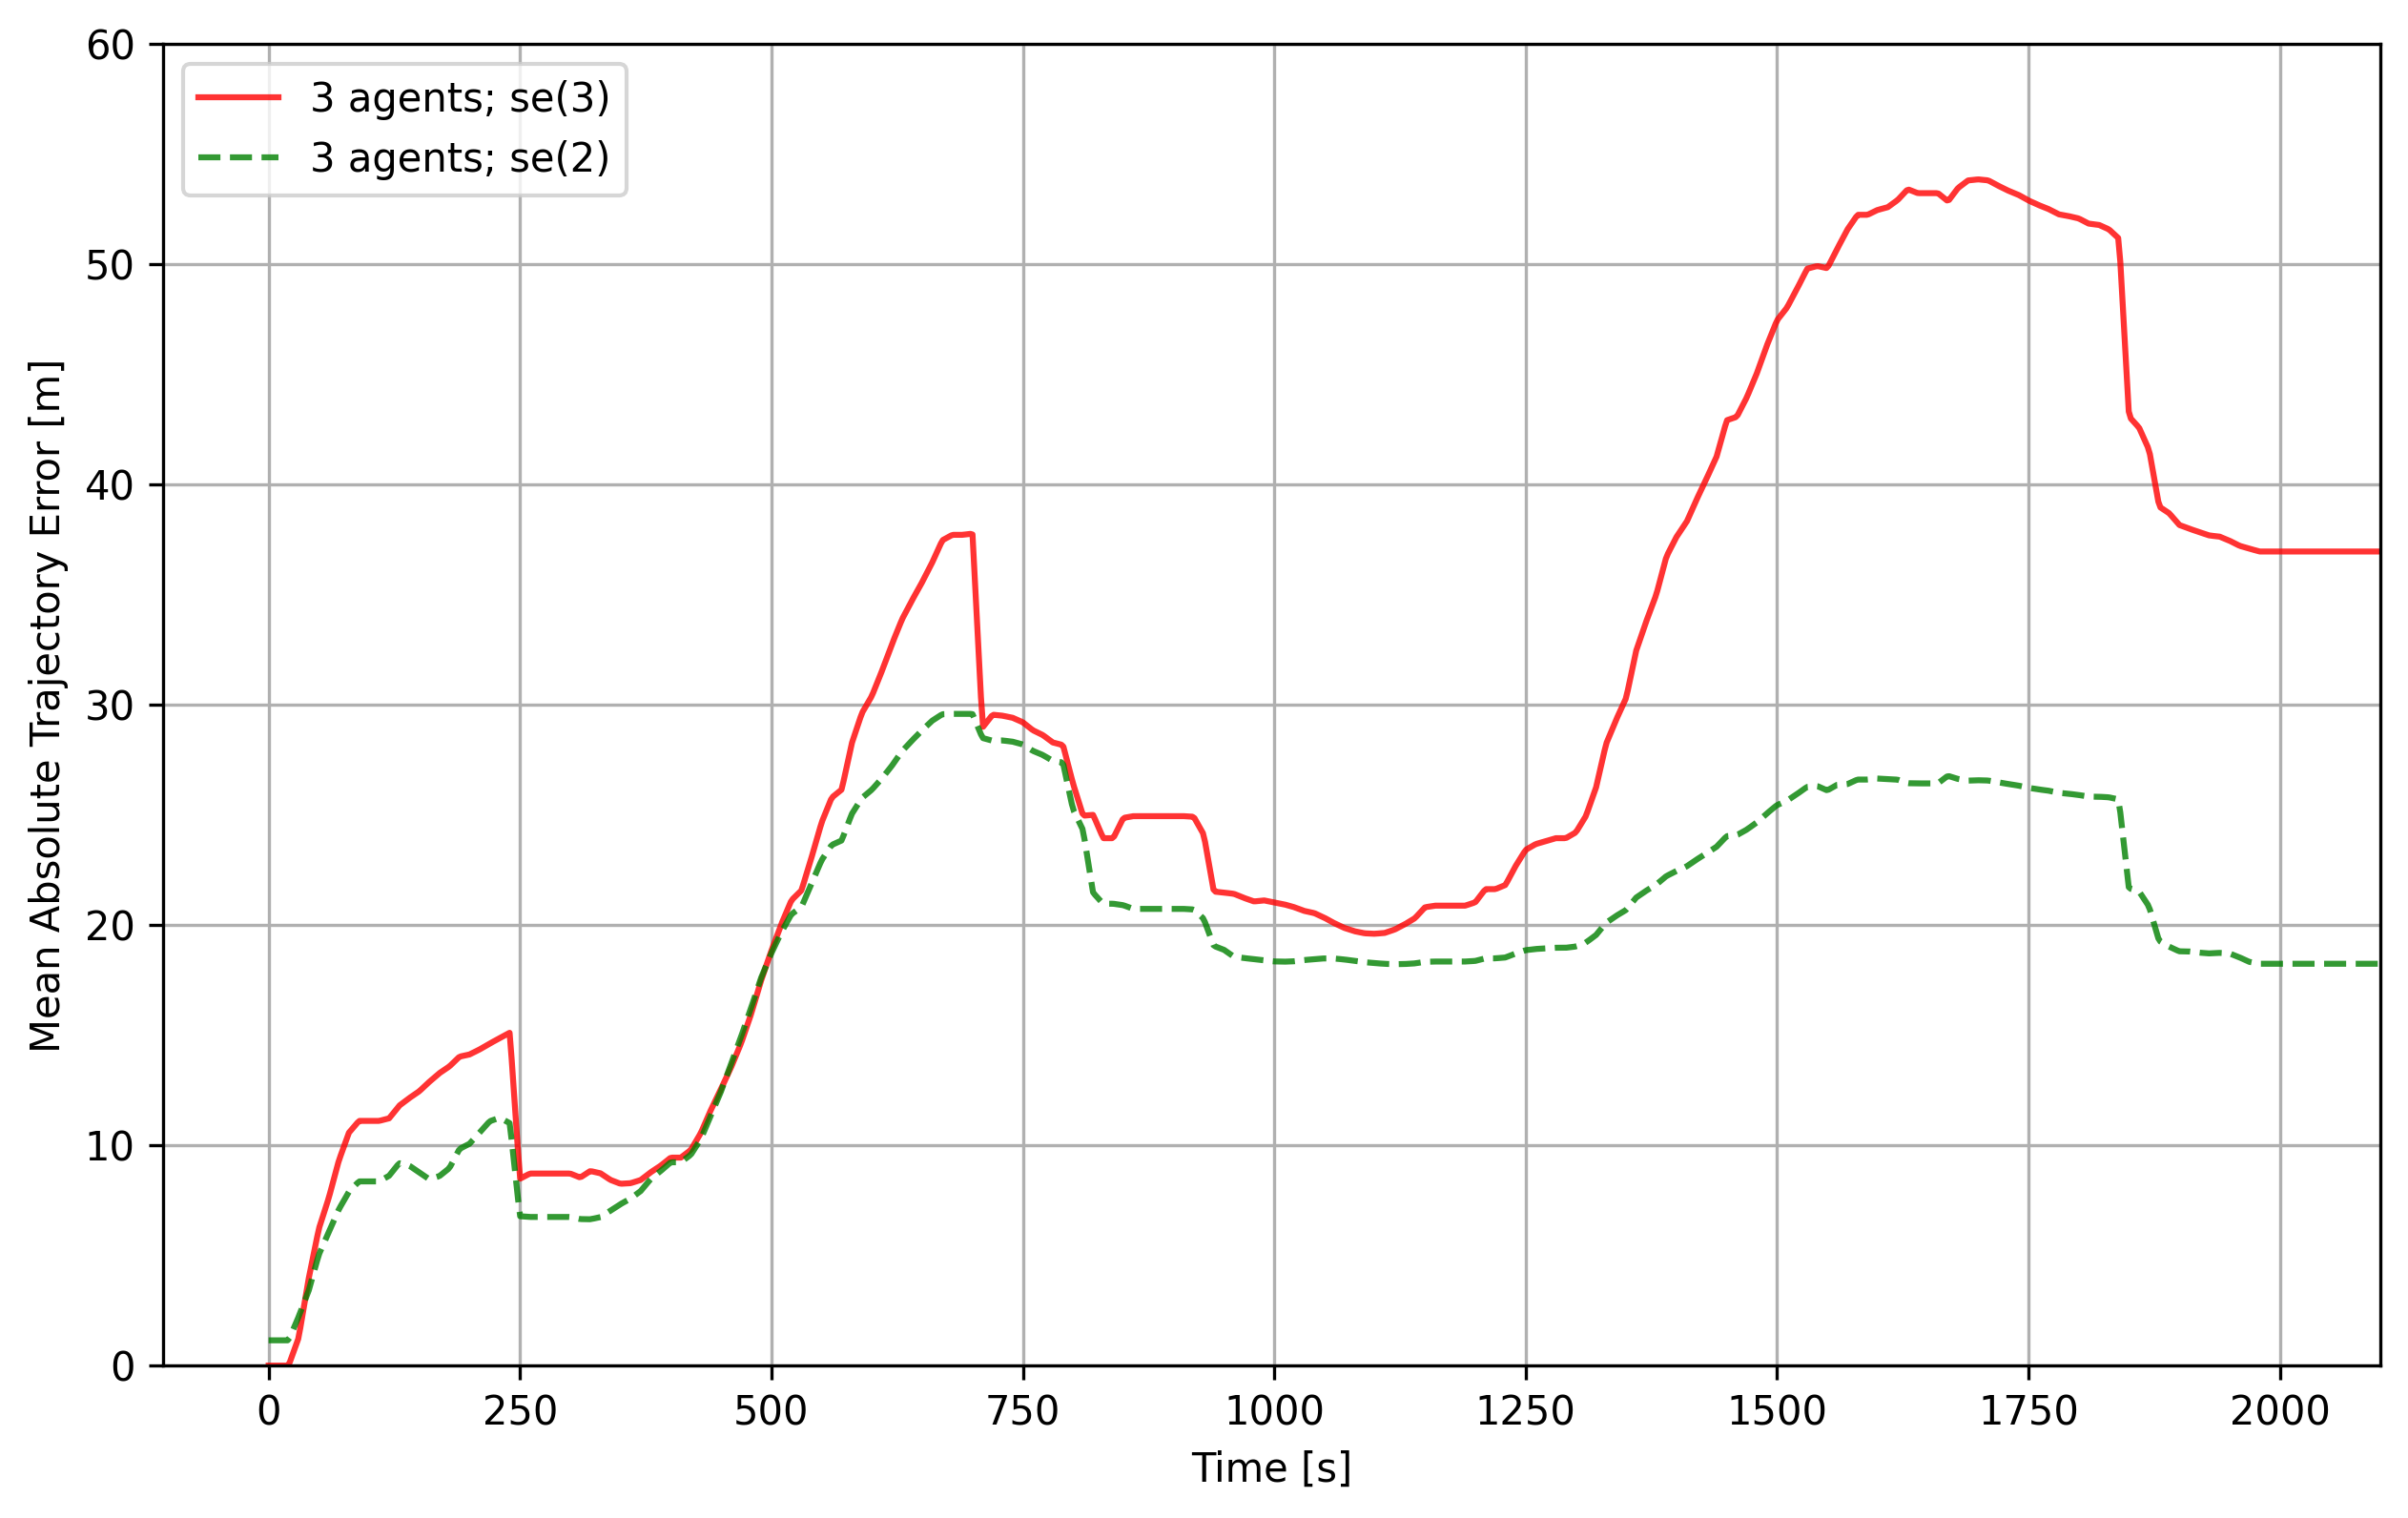

In [25]:
import matplotlib.pyplot as plt

# Render a matplotlib plot with all three agents mean ATE and std uncertainty areas
plt.figure(figsize=(10, 6))
# increase dpi
plt.rcParams['figure.dpi'] = 300

colors = ['red', 'green', 'blue', 'orange', 'C5']
linestyle = ['solid', 'dashed', 'solid', 'solid', 'solid']

for i,seq in enumerate(seqs):
    timestamps = x #[m["timestamp"] for m in seq["metrics"]]
    ate = seq["ate_interp"] #[m["mean_ate"] for m in seq["metrics"]]
    # std = [m["std_ate"] for m in seq["metrics"]]
    
    # labels = ["time factor = 0.1x", "time factor = 0.1x", "time factor = 0.2x", "time factor = 0.5x (cores split)", "time factor = 0.5x (cores shared)"]
    labels = ["se(3)", "se(2)", "time factor = 0.2x", "time factor = 0.5x (cores split)", "time factor = 0.5x (cores shared)"]
    # label = f'{seq["n_agents"]} agent{"s" if seq["n_agents"] > 1 else ""} (dyn. points {"" if seq["remove_dyn"] else "not"} removed)'
    plt.plot(timestamps, ate, label=f"3 agents; {labels[i]}", color=colors[i], linestyle=linestyle[i], alpha=0.8)
    
plt.xlabel('Time [s]')
plt.ylabel('Mean Absolute Trajectory Error [m]')
plt.legend()
# cut negative values
plt.ylim(bottom=0)
# plt.ylim(top=max(max(mate_0), max(mate_1), max(mate_2)) + 10)
plt.ylim(top=60)
# plt.xlim(left=1000)
plt.xlim(right=end_stamp)
# plt.xlim(right=1700, left=1680)
# plt.title('Determinism test for runs with 3 agents at different slowdown factors')

# make custom legend distinguishing dashed/solid and colors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# handles = [
#     mlines.Line2D([], [], color='black', linestyle='solid', label='Dynamic points removed'),
#     mlines.Line2D([], [], color='black', linestyle='dashed', label='Dynamic points not removed'),
#     mlines.Line2D([], [], color='red', linestyle='solid', label='1 agent'),
#     mlines.Line2D([], [], color='green', linestyle='solid', label='2 agents'),
#     mlines.Line2D([], [], color='blue', linestyle='solid', label='3 agents'),
# ]
# plt.legend(handles=handles)

plt.grid()

plt.show()
